# 06 · Final Gaussian versus matched Student-t

**Question:** Does adding fat tails help when prior centers, variance budgets, feature coefficients, signed interstate relationships and polling corrections are held fixed?

This compares the final Gaussian with a new **df=5, variance-matched componentwise Student** version. National, signed-pattern, local electoral and polling residuals get heavy tails. Feature-coefficient uncertainty and extra observation noise remain Gaussian. This is different from the older Student helper in notebook 01.

No data download, historical refitting, df selection or model promotion occurs. The sampler checks every Gaussian control and convergence. See [the full specification](../docs/MATCHED_STUDENT.md). Run notebook 04 first for newer current evidence; identical sources reuse the verified comparison cache.

In [2]:
from pathlib import Path
import sys,json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),Path.cwd().parent] if (p/'election_lab.py').exists())
sys.path.insert(0,str(ROOT))
import election_lab as lab
from model_labels import display, model_label
from matched_student import run,LABEL
INCLUDE_LIVE=True
FORCE=False
RECENT_FIRST_CYCLE=2016
RUN=lab.run_logged(run,include_live=INCLUDE_LIVE,force=FORCE)
meta=json.loads((RUN/'run.json').read_text())
pred=pd.read_parquet(RUN/'predictions.parquet')
seats=pd.read_parquet(RUN/'seats.parquet')
REVIEW=lab.new_run('matched_student_review')
print('Sampler run:',RUN.relative_to(ROOT))
print('Current source:',meta['source_live'])
if meta['live_metadata']:
    print('Current cutoff:',meta['live_metadata']['as_of'],'| stale sources:',meta['live_metadata']['freshness'].get('stale_sources',[]))


Run log: cache/logs/run_20260921T185915.749337Z.txt
Sampler run: cache/runs/matched_student/20260921T185915.825631Z
Current source: cache/runs/live/20260921T185745.202426Z
Current cutoff: 2026-09-21 | stale sources: []


## Historical accuracy and predictive distributions

Historical folds use earlier cycles for calibration. The same races, labels and poll evidence are used by both models. Primary summary: 2016–2024, five cycles at each horizon. Margins are **D−R percentage points**.

MAE, Brier and weighted interval score (WIS) are lower-is-better. Coverage should be close to the nominal 70%/95%, not simply as high as possible. Accuracy and coverage below pool contests; MAE/Brier/WIS/width first average within cycle, then give cycles equal weight. Classification uses the sign of predicted mean.

In [3]:
hist=pred[pred.evidence.eq('frozen') & pred.cycle.between(RECENT_FIRST_CYCLE,2024)].copy()
metrics=['absolute_error_pp','brier','wis_pp','width70_pp','width95_pp']
cycle=hist.groupby(['scenario','model','cycle'])[metrics].mean().reset_index()
summary=cycle.groupby(['scenario','model'])[metrics].mean()
counts=hist.groupby(['scenario','model']).agg(races=('target_id','size'),correct=('correct','sum'),coverage70=('coverage70','mean'),coverage95=('coverage95','mean'))
summary=summary.join(counts).reset_index()
summary['accuracy_pct']=100*summary.correct/summary.races
summary[['coverage70','coverage95']]*=100
summary.to_csv(REVIEW/'historical_summary.csv',index=False)
display(summary[['scenario','model','races','correct','accuracy_pct','absolute_error_pp','brier']].round(4))
display(summary[['scenario','model','width70_pp','coverage70','width95_pp','coverage95','wis_pp']].round(3))
chamber=seats[seats.evidence.eq('frozen') & seats.cycle.between(RECENT_FIRST_CYCLE,2024)]
print('Chamber CRPS and expected-seat absolute error: lower is better')
display(chamber.groupby(['scenario','model'])[['seat_crps','expected_seat_error']].mean().round(4))


,scenario,model,races,correct,accuracy_pct,absolute_error_pp,brier
0,matched_live,Gaussian Bayesian,140,128.0,91.4286,6.3067,0.0555
1,matched_live,Matched Student-t (df5),140,129.0,92.1429,6.3443,0.0548
2,oct31,Gaussian Bayesian,140,132.0,94.2857,5.2060,0.0504
3,oct31,Matched Student-t (df5),140,132.0,94.2857,5.2242,0.0495


,scenario,model,width70_pp,coverage70,width95_pp,coverage95,wis_pp
0,matched_live,Gaussian Bayesian,19.876,78.571,37.588,94.286,3.822
1,matched_live,Matched Student-t (df5),16.929,66.429,35.084,92.857,3.783
2,oct31,Gaussian Bayesian,15.800,73.571,29.878,94.286,3.054
3,oct31,Matched Student-t (df5),13.287,62.143,26.851,92.143,3.049


Chamber CRPS and expected-seat absolute error: lower is better


seat_crps  expected_seat_error
scenario     model                                                  
matched_live Gaussian Bayesian           0.7046               1.1331
             Matched Student-t (df5)     0.7686               1.2424
oct31        Gaussian Bayesian           0.6633               0.9458
             Matched Student-t (df5)     0.6828               0.9729

## Every evaluated historical cycle

Each row is one held-out election cycle. The tables include earlier 2012/2014 folds as well as the primary recent period. Close mean margins can change winner classification without a large margin-error difference. Repeated architecture exploration means these are research hindcasts, not a pristine final holdout.

In [4]:
per_cycle=pd.read_parquet(RUN/'cycle_scores.parquet')
per_cycle.to_csv(REVIEW/'by_cycle.csv',index=False)
for horizon in ['matched_live','oct31']:
    print(horizon,'— margin MAE (pp)')
    table=per_cycle[per_cycle.scenario.eq(horizon)]
    display(table.pivot(index='cycle',columns='model',values='absolute_error_pp').round(3))
    print('Correct winner calls; same number of races for both models')
    display(table.pivot(index='cycle',columns='model',values='correct').astype(int).join(table.groupby('cycle').n.first().rename('races')))


matched_live — margin MAE (pp)


model,Gaussian Bayesian,Matched Student-t (df5)
cycle,,
2012,7.486,7.605
2014,10.222,10.239
2016,7.846,7.808
2018,3.761,3.871
2020,7.847,7.909
2022,7.391,7.388
2024,4.688,4.745


Correct winner calls; same number of races for both models


,Gaussian Bayesian,Matched Student-t (df5),races
cycle,,,
2012,29,28,31
2014,23,23,27
2016,23,24,29
2018,28,28,30
2020,25,25,27
2022,25,25,26
2024,27,27,28


oct31 — margin MAE (pp)


model,Gaussian Bayesian,Matched Student-t (df5)
cycle,,
2012,5.400,5.494
2014,5.545,5.454
2016,6.629,6.600
2018,3.442,3.448
2020,6.345,6.396
2022,5.327,5.332
2024,4.287,4.345


Correct winner calls; same number of races for both models


,Gaussian Bayesian,Matched Student-t (df5),races
cycle,,,
2012,30,30,31
2014,26,25,27
2016,24,24,29
2018,30,30,30
2020,25,25,27
2022,26,26,26
2024,27,27,28


## Current seats and every state

Choose `live` for the latest saved live evidence or `frozen` for the September 17 reproduction. Both models in each view receive identical evidence. Expected seats sum state probabilities plus continuing seats; point seats count positive mean margins. Control probability comes from joint draws, with D control requiring 51 seats. Current labels are unknown.

In [5]:
EVIDENCE='live' if INCLUDE_LIVE else 'frozen'
current=pred[pred.evidence.eq(EVIDENCE)&pred.cycle.eq(2026)].copy()
now=seats[seats.evidence.eq(EVIDENCE)&seats.cycle.eq(2026)].copy()
now['D control %']=100*now.p_D_control
now['70% D seats']=now.D_lo70.astype(str)+'–'+now.D_hi70.astype(str)
display(now[['model','point_D','point_R','expected_D','D control %','70% D seats']].round(3))
current['D win %']=100*current.p_dem
state=current.pivot(index='geography',columns='model',values=['margin_pp','D win %','lo70_pp','hi70_pp'])
display(state.round(2))
now.to_csv(REVIEW/'current_seats.csv',index=False)
current[['model','geography','margin_pp','D win %','lo70_pp','hi70_pp']].to_csv(REVIEW/'current_states.csv',index=False)


,model,point_D,point_R,expected_D,D control %,70% D seats
30,Gaussian Bayesian,51,49,50.320,45.520,49–52
31,Matched Student-t (df5),51,49,50.476,50.028,49–52


margin_pp                                   D win %  \
model     Gaussian Bayesian Matched Student-t (df5) Gaussian Bayesian   
geography                                                               
AK                    -3.10                   -2.87             30.01   
AL                   -22.02                  -21.94              0.04   
AR                   -20.80                  -19.23              0.17   
CO                    17.44                   17.62             92.75   
DE                    24.95                   25.15             99.92   
FL                    -5.48                   -5.32             20.29   
GA                     5.22                    5.31             80.84   
IA                    -3.27                   -3.08             29.18   
ID                   -25.97                  -25.75              0.02   
IL                    22.02                   22.20             99.60   
KS                    -8.39                   -7.79              6.37   
KY                   -13.60                  -13.40              1.37   
LA                   -15.98                  -15.79              2.71   
MA                    25.62                   25.66            100.00   
ME                     8.19                    7.96             92.00   
MI                     4.99                    4.90             79.94   
MN                     8.39                    8.59             87.90   
MS                   -11.64                  -11.58              2.38   
MT                   -18.69                  -18.95              0.37   
NC                     4.75                    4.94             82.58   
NE                   -24.08                  -23.91              3.51   
NH                     9.98                    9.41             95.41   
NJ                    17.72                   17.90             99.62   
NM                    15.59                   15.74             98.11   
OH                     2.77                    2.90             68.66   
OK                   -27.86                  -27.63              0.05   
OR                    23.07                   23.18             99.87   
RI                    27.17                   27.72             99.95   
SC                   -10.92                  -10.55              3.32   
SD                   -34.05                  -33.88              0.02   
TN                   -21.44                  -21.24              0.48   
TX                     0.06                    0.13             50.51   
VA                    16.45                   16.63             98.41   
WV                   -32.47                  -32.40              5.68   
WY                   -43.33                  -43.16              0.00   

                                            lo70_pp                          \
model     Matched Student-t (df5) Gaussian Bayesian Matched Student-t (df5)   
geography                                                                     
AK                          27.48             -9.22                   -7.98   
AL                           0.14            -28.80                  -27.94   
AR                           0.80            -28.14                  -26.05   
CO                          94.28              5.03                    6.80   
DE                          99.56             16.73                   18.00   
FL                          15.10            -12.30                  -10.57   
GA                          86.39             -0.98                    0.30   
IA                          25.78             -9.44                   -7.98   
ID                           0.29            -33.64                  -32.44   
IL                          99.16             13.42                   14.71   
KS                           6.37            -14.09                  -12.83   
KY                           1.01            -19.98                  -18.64   
LA                           2.87            -24.59       

## What changed in uncertainty?

Equal prior variance does not imply equally wide central intervals. A variance-matched t distribution can be more concentrated near its center while allowing more extreme tails. Posterior error scales also adapt to the observed polls. The left chart checks actual 70% coverage; the right compares current state probabilities, with the diagonal indicating no change.

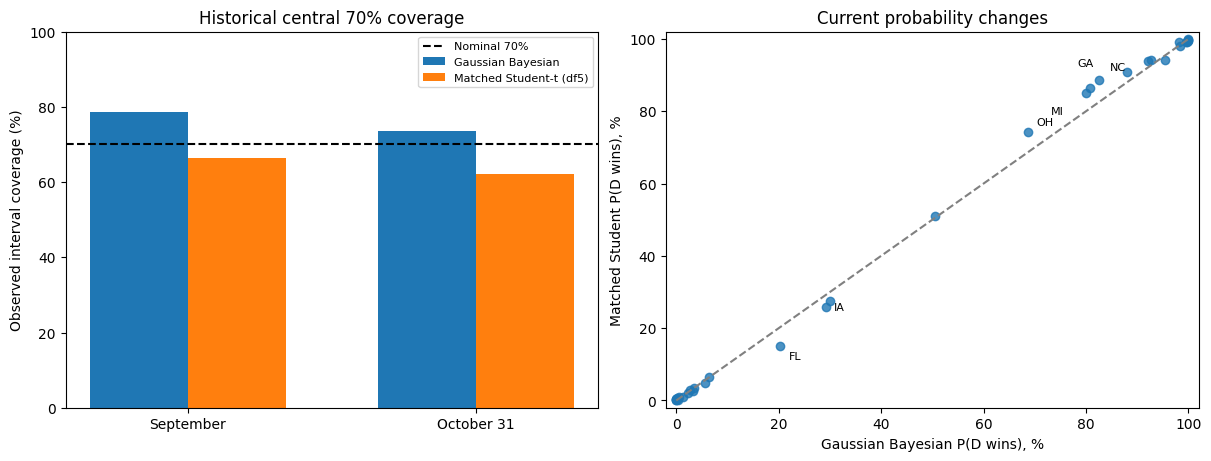

In [6]:
fig,axes=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
models=['Bayesian',LABEL];x=np.arange(2)
for i,model in enumerate(models):
    rows=summary[summary.model.eq(model)].set_index('scenario').loc[['matched_live','oct31']]
    axes[0].bar(x+(i-.5)*.34,rows.coverage70,width=.34,label=model_label(model))
axes[0].axhline(70,color='black',ls='--',label='Nominal 70%')
axes[0].set(xticks=x,xticklabels=['September','October 31'],ylabel='Observed interval coverage (%)',ylim=(0,100),title='Historical central 70% coverage')
axes[0].legend(fontsize=8)
prob=current.pivot(index='geography',columns='model',values='D win %')
axes[1].scatter(prob['Bayesian'],prob[LABEL],alpha=.8)
axes[1].plot([0,100],[0,100],ls='--',color='gray')
for st in (prob[LABEL]-prob.Bayesian).abs().nlargest(6).index:
    axes[1].annotate(st,(prob.loc[st,'Bayesian'],prob.loc[st,LABEL]),xytext={'MI':(-25,-15),'GA':(-9,16),'NC':(8,7),'OH':(6,5),'FL':(6,-10),'IA':(6,-2)}.get(st,(5,5)),textcoords='offset points',fontsize=8)
axes[1].set(xlabel='Gaussian Bayesian P(D wins), %',ylabel='Matched Student P(D wins), %',xlim=(-2,102),ylim=(-2,102),title='Current probability changes')
fig.savefig(REVIEW/'matched_comparison.png',dpi=160)
plt.show()


## Numerical checks and scope

Every fold must reproduce the exact final Gaussian when scales are fixed to one. All Student chains must pass R-hat<1.01 and bulk/tail ESS≥400. Tests also compare a scalar Student prior with its known distribution, and an observed scalar posterior with independent numerical quadrature.

These checks verify computation, not model adequacy. Compare margins, calibration and chamber scores together. Keep the final Gaussian as main unless subsequent evidence supports a change; no winner is automatically selected here.

In [7]:
checks=pd.read_parquet(RUN/'checks.parquet')
assert checks.prior_matched.all() and checks.gaussian_control.all()
assert checks.max_rhat.lt(1.01).all() and checks.min_ess.ge(400).all()
assert pred[pred.cycle.eq(2026)].actual.isna().all()
display(checks[['evidence','scenario','cycle','max_rhat','min_ess','draws_per_chain']].round(4))
lab.verify_run(RUN)
lab.finish(REVIEW,dict(source=str(RUN.relative_to(ROOT)),source_manifest_sha256=lab.sha(RUN/'manifest.json'),current_evidence=EVIDENCE,first_cycle=RECENT_FIRST_CYCLE,promotion=False))
print('Validated comparison and review:',REVIEW.relative_to(ROOT))


,evidence,scenario,cycle,max_rhat,min_ess,draws_per_chain
0,frozen,matched_live,2012,1.0012,4059.5490,4000
1,frozen,matched_live,2014,1.0010,5324.7522,4000
2,frozen,matched_live,2016,1.0014,7608.3946,4000
3,frozen,matched_live,2018,1.0022,3729.9015,4000
4,frozen,matched_live,2020,1.0011,5466.1137,4000
5,frozen,matched_live,2022,1.0009,6477.2318,4000
6,frozen,matched_live,2024,1.0010,5873.3817,4000
7,frozen,matched_live,2026,1.0011,6151.5630,4000
8,frozen,oct31,2012,1.0054,2742.3927,4000
9,frozen,oct31,2014,1.0021,2977.3910,4000


Validated comparison and review: cache/runs/matched_student_review/20260921T185940.592697Z


## Saved reports

[Read the published report](../outputs/reports/experiments/matched_student_review.md) · [All outputs and dated reports](../outputs/README.md)
